<a href="https://colab.research.google.com/github/ziadabdullah007/Deep_Learning_Project/blob/main/resnet50_bilstm_attention_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# CNN FEATURE EXTRACTION
# RESNET50 VERSION
# AI MENU DESCRIPTION + FOOD RECOMMENDATION
# =========================================

import pandas as pd
import numpy as np
import os
import pickle

from tqdm import tqdm

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from tensorflow.keras.models import Model


# ======================================================
# 1. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)


# ======================================================
# 2. FIX IMAGE PATHS FOR KAGGLE
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images"
)

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(
        images_folder,
        os.path.basename(x)
    )
)


# ======================================================
# 3. LOAD PRETRAINED CNN MODEL
# ======================================================

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("\nRESNET50 MODEL LOADED ✅")


# ======================================================
# 4. FEATURE EXTRACTION FUNCTION
# ======================================================

def extract_features(img_path):

    try:

        img = load_img(
            img_path,
            target_size=(224, 224)
        )

        img = img_to_array(img)

        img = np.expand_dims(img, axis=0)

        img = preprocess_input(img)

        features = model.predict(
            img,
            verbose=0
        )

        features = features.flatten()

        return features

    except Exception as e:

        print(f"\nERROR WITH IMAGE:")
        print(img_path)

        return None


# ======================================================
# 5. EXTRACT FEATURES FROM ALL IMAGES
# ======================================================

features_dict = {}

print("\nEXTRACTING FEATURES...\n")

for idx, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    img_path = row["image_path"]

    features = extract_features(img_path)

    if features is not None:

        image_name = os.path.basename(img_path)

        features_dict[image_name] = features


# ======================================================
# 6. SAVE FEATURES
# ======================================================

save_path = "/kaggle/working/featuresRESNET50.pkl"

with open(save_path, "wb") as f:

    pickle.dump(features_dict, f)

print("\nFEATURES SAVED ✅")

print(save_path)


# ======================================================
# 7. SHOW SAMPLE OUTPUT
# ======================================================

sample_key = list(features_dict.keys())[0]

print("\nSAMPLE IMAGE:")
print(sample_key)

print("\nFEATURE VECTOR SHAPE:")
print(features_dict[sample_key].shape)

print("\nFIRST 20 FEATURES:")
print(features_dict[sample_key][:20])


# ======================================================
# 8. TOTAL FEATURES EXTRACTED
# ======================================================

print("\nTOTAL IMAGES PROCESSED:")
print(len(features_dict))

2026-05-12 12:38:47.720733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778589527.939012      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778589527.998668      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778589528.471708      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778589528.471777      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778589528.471780      57 computation_placer.cc:177] computation placer alr

DATASET SHAPE:
(21127, 8)


I0000 00:00:1778589551.624748      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

RESNET50 MODEL LOADED ✅

EXTRACTING FEATURES...



  0%|          | 0/21127 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1778589561.103311     124 service.cc:152] XLA service 0x7b96dc001470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778589561.103375     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778589562.032628     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778589564.592239     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
 24%|██▍       | 5152/21127 [07:52<25:16, 10.54it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 21127/21127 [31:57<00:00, 11.02it/s]



FEATURES SAVED ✅
/kaggle/working/featuresRESNET50.pkl

SAMPLE IMAGE:
img_0.jpg

FEATURE VECTOR SHAPE:
(2048,)

FIRST 20 FEATURES:
[0.5313381  1.8675283  2.0470839  0.14424762 0.         0.0129994
 0.04873355 0.03927743 0.10723779 0.         0.1714801  0.10771074
 0.17779389 0.         0.03565812 0.11868122 0.09284879 0.05227278
 0.95229775 0.05052096]

TOTAL IMAGES PROCESSED:
21127


In [ ]:

import pandas as pd
import numpy as np
import os
import pickle

In [ ]:
import pandas as pd
import numpy as np
import pickle
import re
import os
import tensorflow as tf

from tqdm import tqdm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    Bidirectional,
    BatchNormalization,
    Attention,
    Concatenate,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import Sequence

from sklearn.model_selection import train_test_split


# ======================================================
# MIXED PRECISION
# ======================================================

tf.keras.mixed_precision.set_global_policy(
    'mixed_float16'
)

print("MIXED PRECISION ENABLED ✅")


# ======================================================
# 1. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)


# ======================================================
# 2. FIX IMAGE PATHS
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images"
)

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(
        images_folder,
        os.path.basename(x)
    )
)


# ======================================================
# 3. LOAD CNN FEATURES
# ======================================================

with open(
    "/kaggle/working/featuresRESNET50.pkl",
    "rb"
) as f:

    features = pickle.load(f)

print("\nFEATURES LOADED ✅")

print("TOTAL FEATURES:")
print(len(features))


# ======================================================
# 4. CLEAN TEXT
# ======================================================

def clean_ingredient(text):

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z, ]', '', text)

    return text.strip()


# ======================================================
# 5. CREATE SHORT CAPTIONS
# ======================================================

def create_short_caption(row):

    title = str(row["title"]).lower()

    ingredients = str(row["ingredients"]).split("|")

    ingredients = [
        clean_ingredient(x)
        for x in ingredients
    ]

    ingredients = [
        x for x in ingredients
        if len(x.strip()) > 2
    ]

    ingredients = ingredients[:3]

    ingredients_text = ", ".join(ingredients)

    caption = (
        f"<start> {title} with {ingredients_text} <end>"
    )

    return caption


df["refined_caption"] = df.apply(
    create_short_caption,
    axis=1
)

print("\nCAPTIONS CREATED ✅")


# ======================================================
# 6. TOKENIZER
# ======================================================

captions = df["refined_caption"].tolist()

tokenizer = Tokenizer(
    oov_token="<unk>"
)

tokenizer.fit_on_texts(captions)

vocab_size = len(tokenizer.word_index) + 1

print("\nVOCAB SIZE:")
print(vocab_size)


# ======================================================
# 7. MAX LENGTH
# ======================================================

max_length = 20

print("\nMAX LENGTH:")
print(max_length)


# ======================================================
# 8. TRAIN TEST SPLIT
# ======================================================

train_df, val_df = train_test_split(

    df,

    test_size=0.1,

    random_state=42
)

print("\nTRAIN TEST SPLIT DONE ✅")

print("TRAIN:", train_df.shape)

print("VALID:", val_df.shape)


# ======================================================
# 9. DATA GENERATOR
# ======================================================

class DataGenerator(Sequence):

    def __init__(
        self,
        dataframe,
        features,
        tokenizer,
        max_length,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.features = features

        self.tokenizer = tokenizer

        self.max_length = max_length

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.indexes = np.arange(len(self.dataframe))

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.floor(len(self.dataframe) / self.batch_size)
        )

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):

        batch_indexes = self.indexes[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        X1 = []
        X2 = []
        y = []

        for idx in batch_indexes:

            row = self.dataframe.iloc[idx]

            image_name = row["image_path"].split("/")[-1]

            if image_name not in self.features:
                continue

            image_features = self.features[image_name]

            caption = row["refined_caption"]

            seq = self.tokenizer.texts_to_sequences(
                [caption]
            )[0]

            for i in range(1, len(seq)):

                in_seq = seq[:i]

                out_seq = seq[i]

                in_seq = pad_sequences(
                    [in_seq],
                    maxlen=self.max_length
                )[0]

                X1.append(image_features)

                X2.append(in_seq)

                y.append(out_seq)

        return (

            (
                np.array(X1, dtype=np.float32),

                np.array(X2, dtype=np.int32)
            ),

            np.array(y, dtype=np.int32)
        )


# ======================================================
# 10. CREATE GENERATORS
# ======================================================

train_generator = DataGenerator(

    train_df,

    features,

    tokenizer,

    max_length,

    batch_size=32
)

val_generator = DataGenerator(

    val_df,

    features,

    tokenizer,

    max_length,

    batch_size=32,

    shuffle=False
)

print("\nDATA GENERATORS READY ✅")


# ======================================================
# 11. IMAGE FEATURE BRANCH
# ======================================================

inputs1 = Input(shape=(2048,))

fe1 = Dropout(0.5)(inputs1)

fe2 = Dense(
    512,
    activation='relu'
)(fe1)

fe2 = BatchNormalization()(fe2)

fe2 = Dropout(0.4)(fe2)


# ======================================================
# 12. TEXT BRANCH
# ======================================================

inputs2 = Input(shape=(max_length,))

se1 = Embedding(

    vocab_size,

    256,

    mask_zero=False

)(inputs2)

se2 = Dropout(0.5)(se1)

# First BiLSTM
se3 = Bidirectional(

    LSTM(
        128,
        return_sequences=True
    )

)(se2)

# Second BiLSTM
se4 = Bidirectional(

    LSTM(
        128,
        return_sequences=True
    )

)(se3)

# Attention
attention = Attention()([se4, se4])

# Pooling
se5 = GlobalAveragePooling1D()(attention)

se5 = Dropout(0.4)(se5)


# ======================================================
# 13. MERGE BRANCHES
# ======================================================

decoder1 = Concatenate()([fe2, se5])

decoder2 = Dense(
    512,
    activation='relu'
)(decoder1)

decoder2 = BatchNormalization()(decoder2)

decoder2 = Dropout(0.5)(decoder2)

outputs = Dense(

    vocab_size,

    activation='softmax',

    dtype='float32'

)(decoder2)


# ======================================================
# 14. BUILD MODEL
# ======================================================

model = Model(

    inputs=[inputs1, inputs2],

    outputs=outputs
)

optimizer = Adam(
    learning_rate=0.0003
)

loss_function = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(

    loss=loss_function,

    optimizer=optimizer,

    metrics=['accuracy']
)

print("\nMODEL SUMMARY:\n")

model.summary()


# ======================================================
# 15. CALLBACKS
# ======================================================

checkpoint = ModelCheckpoint(

    "/kaggle/working/best_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=4,

    restore_best_weights=True
)


# ======================================================
# 16. TRAIN MODEL
# ======================================================

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=30,

    callbacks=[
        checkpoint,
        early_stop
    ]
)


# ======================================================
# 17. SAVE TOKENIZER
# ======================================================

with open(
    "/kaggle/working/tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(tokenizer, f)

print("\nTOKENIZER SAVED ✅")


# ======================================================
# 18. SAVE MODEL
# ======================================================

model.save(
    "/kaggle/working/final_model.keras"
)

print("\nMODEL SAVED ✅")


# ======================================================
# 19. FINAL INFO
# ======================================================

print("\nTRAINING COMPLETE 🔥")

print("\nFILES SAVED:")

print("/kaggle/working/final_model.keras")

print("/kaggle/working/tokenizer.pkl")

print("/kaggle/working/featuresRESNET50.pkl")

2026-05-12 13:25:19.814513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778592320.004186  253887 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778592320.060872  253887 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778592320.523293  253887 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778592320.523339  253887 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778592320.523343  253887 computation_placer.cc:177] computation placer alr

MIXED PRECISION ENABLED ✅
DATASET SHAPE:
(21127, 8)

FEATURES LOADED ✅
TOTAL FEATURES:
21127

CAPTIONS CREATED ✅

VOCAB SIZE:
11617

MAX LENGTH:
20

TRAIN TEST SPLIT DONE ✅
TRAIN: (19014, 8)
VALID: (2113, 8)

DATA GENERATORS READY ✅


I0000 00:00:1778592343.160079  253887 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



MODEL SUMMARY:



Model: "functional"

...

 Trainable params: 11,166,817 (42.60 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1778592351.428542  253931 cuda_dnn.cc:529] Loaded cuDNN version 91002


594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.0489 - loss: 7.8721
Epoch 1: val_loss improved from inf to 5.61842, saving model to /kaggle/working/best_model.keras
594/594 ━━━━━━━━━━━━━━━━━━━━ 73s 108ms/step - accuracy: 0.0489 - loss: 7.8703 - val_accuracy: 0.1008 - val_loss: 5.6184
Epoch 2/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1074 - loss: 5.5230
Epoch 2: val_loss improved from 5.61842 to 4.98560, saving model to /kaggle/working/best_model.keras
594/594 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.1075 - loss: 5.5227 - val_accuracy: 0.1547 - val_loss: 4.9856
Epoch 3/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1508 - loss: 5.0103
Epoch 3: val_loss improved from 4.98560 to 4.68709, saving model to /kaggle/working/best_model.keras
594/594 ━━━━━━━━━━━━━━━━━━━━ 63s 107ms/step - accuracy: 0.1508 - loss: 5.0102 - val_accuracy: 0.1895 - val_loss: 4.6871
Epoch 4/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1777 - loss: 4.7239
Epoc

MODEL LOADED ✅
TOKENIZER LOADED ✅
FEATURES LOADED ✅
DATASET LOADED ✅
RESNET50 LOADED ✅
FEATURES EXTRACTED ✅


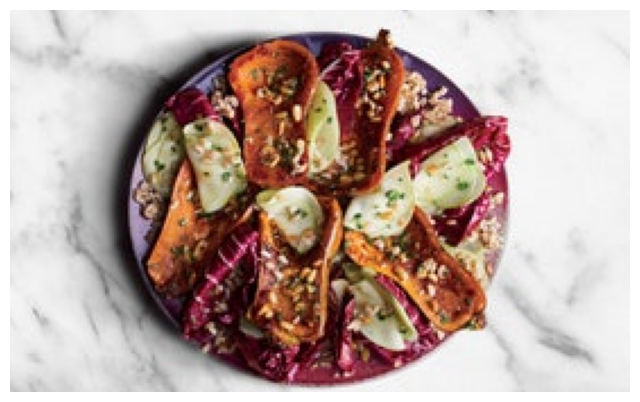

AI MENU DESCRIPTION 🔥

Charred eggplant and cherry salad with tablespoons extravirgin olive oil divided garlic cloves thinly sliced cup finely chopped shallot teaspoon.

RECOMMENDED DISHES 🔥

1. Honeynut Squash With Radicchio and Miso
2. Paella with Tomatoes and Eggs
3. Roasted Cherry Tomato Caprese
4. Salad Ramen
5. Radicchio–Stone Fruit Salad


In [ ]:
# =========================================
# RESNET50 + BiLSTM + ATTENTION
# FOOD IMAGE CAPTION GENERATION
# + FOOD RECOMMENDATION SYSTEM
# FINAL VERSION
# =========================================

import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from PIL import Image

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications.resnet50 import (
    preprocess_input
)

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)


# ======================================================
# 1. LOAD MODEL
# ======================================================

model = load_model(
    "/kaggle/working/final_model.keras"
)

print("MODEL LOADED ✅")


# ======================================================
# 2. LOAD TOKENIZER
# ======================================================

with open(
    "/kaggle/working/tokenizer.pkl",
    "rb"
) as f:

    tokenizer = pickle.load(f)

print("TOKENIZER LOADED ✅")


# ======================================================
# 3. LOAD FEATURES
# ======================================================

with open(
    "/kaggle/working/featuresRESNET50.pkl",
    "rb"
) as f:

    features = pickle.load(f)

print("FEATURES LOADED ✅")


# ======================================================
# 4. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET LOADED ✅")


# ======================================================
# 5. FIX IMAGE PATHS
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images"
)

df["image_path"] = df["image_path"].apply(
    lambda x: images_folder + "/" + x.split("/")[-1]
)


# ======================================================
# 6. MAX LENGTH
# ======================================================

max_length = 20


# ======================================================
# 7. RESNET50 MODEL
# ======================================================

cnn_model = ResNet50(

    weights='imagenet',

    include_top=False,

    pooling='avg'
)

print("RESNET50 LOADED ✅")


# ======================================================
# 8. IMAGE FEATURE EXTRACTION
# ======================================================

def extract_features(img_path):

    img = load_img(
        img_path,
        target_size=(224, 224)
    )

    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    features = cnn_model.predict(
        img,
        verbose=0
    )

    return features.flatten()


# ======================================================
# 9. INDEX -> WORD
# ======================================================

index_to_word = {

    index: word

    for word, index in tokenizer.word_index.items()
}


def idx_to_word(integer):

    return index_to_word.get(integer)


# ======================================================
# 10. GENERATE CAPTION
# ======================================================

def generate_caption(
    model,
    tokenizer,
    photo,
    max_length
):

    in_text = "<start>"

    used_words = []

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences(
            [in_text]
        )[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [
                photo.reshape(1, 2048),
                sequence
            ],
            verbose=0
        )

        yhat_probs = yhat[0]

        # temperature sampling
        temperature = 0.7

        yhat_probs = np.log(
            yhat_probs + 1e-10
        ) / temperature

        exp_preds = np.exp(yhat_probs)

        yhat_probs = (
            exp_preds / np.sum(exp_preds)
        )

        # top-k filtering
        top_k = 5

        top_indices = np.argsort(
            yhat_probs
        )[-top_k:]

        top_probs = yhat_probs[top_indices]

        top_probs = (
            top_probs / np.sum(top_probs)
        )

        yhat = np.random.choice(
            top_indices,
            p=top_probs
        )

        word = idx_to_word(yhat)

        if word is None:
            break

        # stop repetition
        if used_words.count(word) >= 2:
            break

        used_words.append(word)

        in_text += ' ' + word

        if word == '<end>':
            break

    return in_text


# ======================================================
# 11. CLEAN CAPTION
# ======================================================

def clean_caption(caption):

    caption = caption.replace(
        '<start>',
        ''
    )

    caption = caption.replace(
        '<end>',
        ''
    )

    caption = caption.lower()

    words = caption.split()

    cleaned_words = []

    for word in words:

        if len(cleaned_words) > 0:

            if word == cleaned_words[-1]:
                continue

        cleaned_words.append(word)

    final_words = []

    word_counts = {}

    for word in cleaned_words:

        if word not in word_counts:
            word_counts[word] = 0

        if word_counts[word] < 2:

            final_words.append(word)

            word_counts[word] += 1

    final_words = final_words[:20]

    caption = " ".join(final_words)

    caption = caption.capitalize()

    if not caption.endswith("."):
        caption += "."

    return caption


# ======================================================
# 12. RECOMMEND SIMILAR DISHES
# ======================================================

def recommend_dishes(
    query_features,
    features_dict,
    top_n=5
):

    image_names = list(
        features_dict.keys()
    )

    feature_vectors = np.array(
        list(features_dict.values())
    )

    similarities = cosine_similarity(
        [query_features],
        feature_vectors
    )[0]

    top_indices = similarities.argsort(
    )[-top_n:][::-1]

    recommendations = []

    for idx in top_indices:

        image_name = image_names[idx]

        matched_row = df[
            df['image_path'].str.contains(
                image_name
            )
        ]

        if len(matched_row) > 0:

            title = matched_row.iloc[0][
                'title'
            ]

            recommendations.append(title)

    return recommendations


# ======================================================
# 13. TEST IMAGE
# ======================================================

test_image = (
    "/kaggle/input/datasets/ziadabdullah000/data-food/final_food_data/all_images/img_10074.jpg"
)


# ======================================================
# 14. EXTRACT FEATURES
# ======================================================

query_features = extract_features(
    test_image
)

print("FEATURES EXTRACTED ✅")


# ======================================================
# 15. GENERATE CAPTION
# ======================================================

raw_caption = generate_caption(

    model,

    tokenizer,

    query_features,

    max_length
)

caption = clean_caption(
    raw_caption
)


# ======================================================
# 16. RECOMMENDATIONS
# ======================================================

recommendations = recommend_dishes(

    query_features,

    features,

    top_n=5
)


# ======================================================
# 17. DISPLAY RESULTS
# ======================================================

img = Image.open(test_image)

plt.figure(figsize=(8, 8))

plt.imshow(img)

plt.axis('off')

plt.show()


print("=" * 60)

print("AI MENU DESCRIPTION 🔥\n")

print(caption)

print("\n" + "=" * 60)

print("RECOMMENDED DISHES 🔥\n")

for i, rec in enumerate(
    recommendations,
    1
):

    print(f"{i}. {rec}")